Student ID - 24198170 
Name - Mohd Nizam Mohd Nasir Shaikh
MSc in FinTech (MSCFTD1)

# SAML-D Transactions: Exploratory Data Analysis (EDA) + Money Logic Analytics

## Learning goals
By the end of this notebook, you will be able to:
- Load and clean transactional data
- Perform exploratory data analysis (EDA) with descriptive statistics
- Visualize transaction patterns using multiple chart types
- Investigate suspicious transactions using feature interactions
- Apply "money logic" checks (thresholding, structuring/smurfing, currency/location mismatches)
- Communicate findings with clear plots and written interpretation

## Deliverables
1. Completed notebook with code + outputs
2. Short written summary (max 150-200 words) answering:
   - What patterns distinguish suspicious vs normal transactions?
   - Which locations/currencies/payment types appear higher-risk?
   - What are 2–3 limitations of your analysis?

What patterns distinguish suspicious vs normal transactions?
unfamiliar timing (nights, weekends)
unfamiliar amounts (very huge, round numbers and under thresholds)
High-risk geographical data (international cross-border payments, risky nation regulations)
Risky payment methodology (cash & wire)
unfamiliar frequency

Which locations/currencies/payment types appear higher-risk?
Huge Risk: Cash transactions, Wire transactions, Money orders, Cayman Islands, British Virgin Islands, Panama,
              Cryptocurrency (Bitcoin, Ethereum, etc.), Various currency conversions, Currency mismatches with no logical business reason
Low Risk: Credit cards, Debit cards, Direct bank transfers, Checks, Domestic transactions

What are 2–3 limitations of your analysis?
Lack of Historical Context, Missing External Data & Label Bias

## 2. Load data
**Task:** Load the dataset file provided by your instructor.

- If it is a CSV: `pd.read_csv(...)`
- If it is Parquet: `pd.read_parquet(...)`


In [1]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("berkanoztas/synthetic-transaction-monitoring-dataset-aml")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: kagglehub in c:\users\nizam\anaconda3\lib\site-packages (0.4.3)

Path to dataset files: C:\Users\Nizam\.cache\kagglehub\datasets\berkanoztas\synthetic-transaction-monitoring-dataset-aml\versions\2


In [2]:
import pandas as pd
df = pd.read_csv(path + "/SAML-D.csv")
print(df.head())

       Time        Date  Sender_account  Receiver_account    Amount  \
0  10:35:19  2022-10-07      8724731955        2769355426   1459.15   
1  10:35:20  2022-10-07      1491989064        8401255335   6019.64   
2  10:35:20  2022-10-07       287305149        4404767002  14328.44   
3  10:35:21  2022-10-07      5376652437        9600420220  11895.00   
4  10:35:21  2022-10-07      9614186178        3803336972    115.25   

  Payment_currency Received_currency Sender_bank_location  \
0        UK pounds         UK pounds                   UK   
1        UK pounds            Dirham                   UK   
2        UK pounds         UK pounds                   UK   
3        UK pounds         UK pounds                   UK   
4        UK pounds         UK pounds                   UK   

  Receiver_bank_location  Payment_type  Is_laundering       Laundering_type  
0                     UK  Cash Deposit              0  Normal_Cash_Deposits  
1                    UAE  Cross-border            

In [3]:
print(df.columns.tolist())

['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Laundering_type']


## 3. Basic inspection
**Tasks**
1. Print shape (rows, columns)
2. Show data types
3. Show missing values per column (counts + percentages)
4. Identify your target label column (expected: `is_suspicious`)


In [4]:
df.shape

(9504852, 12)

In [5]:
df.dtypes

Time                       object
Date                       object
Sender_account              int64
Receiver_account            int64
Amount                    float64
Payment_currency           object
Received_currency          object
Sender_bank_location       object
Receiver_bank_location     object
Payment_type               object
Is_laundering               int64
Laundering_type            object
dtype: object

In [6]:
print(df.isnull().sum())

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64


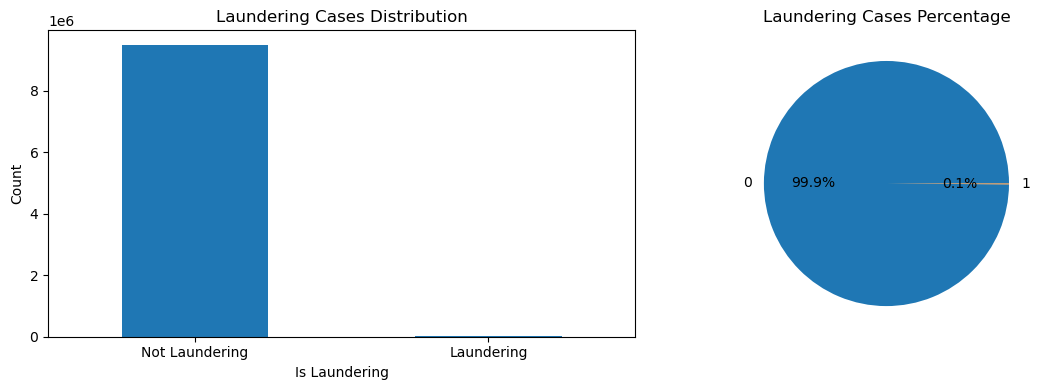

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Is_laundering'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Laundering Cases Distribution')
axes[0].set_xlabel('Is Laundering')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Laundering', 'Laundering'], rotation=0)

# Pie chart
df['Is_laundering'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Laundering Cases Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Time features
**Tasks**
1. Convert the time/date column to datetime
2. Create: hour, day_of_week, month
3. Plot suspicious rate by hour and day-of-week


In [10]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
print(df['DateTime'].head())

0   2022-10-07 10:35:19
1   2022-10-07 10:35:20
2   2022-10-07 10:35:20
3   2022-10-07 10:35:21
4   2022-10-07 10:35:21
Name: DateTime, dtype: datetime64[ns]


In [12]:
df['hour'] = df['DateTime'].dt.hour
# Monday=0, Sunday=6
df['day_of_week'] = df['DateTime'].dt.dayofweek
df['month'] = df['DateTime'].dt.month
print(df[['DateTime', 'hour', 'day_of_week', 'month']].head(10))

             DateTime  hour  day_of_week  month
0 2022-10-07 10:35:19    10            4     10
1 2022-10-07 10:35:20    10            4     10
2 2022-10-07 10:35:20    10            4     10
3 2022-10-07 10:35:21    10            4     10
4 2022-10-07 10:35:21    10            4     10
5 2022-10-07 10:35:21    10            4     10
6 2022-10-07 10:35:23    10            4     10
7 2022-10-07 10:35:23    10            4     10
8 2022-10-07 10:35:26    10            4     10
9 2022-10-07 10:35:29    10            4     10


**Interpretation:** What time patterns do you observe? Are suspicious transactions more common at specific hours/days?


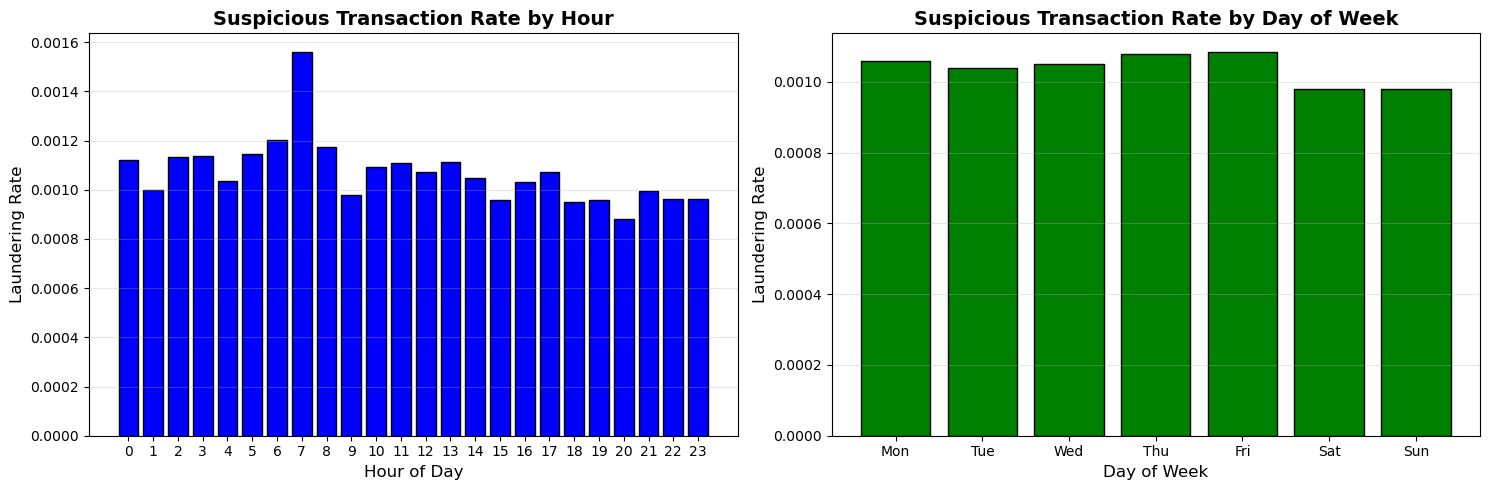

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate suspicious rates
hourly_rate = df.groupby('hour')['Is_laundering'].mean()
daily_rate = df.groupby('day_of_week')['Is_laundering'].mean()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot by hour
axes[0].bar(hourly_rate.index, hourly_rate.values, color='blue', edgecolor='black')
axes[0].set_title('Suspicious Transaction Rate by Hour', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Laundering Rate', fontsize=12)
axes[0].set_xticks(range(24))
axes[0].grid(axis='y', alpha=0.3)

# Plot by day of week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(daily_rate.index, daily_rate.values, color='green', edgecolor='black')
axes[1].set_title('Suspicious Transaction Rate by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Laundering Rate', fontsize=12)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Amount analysis
**Tasks**
1. Basic stats for amount (mean/median/std/min/max, percentiles)
2. Plot distribution of amount for suspicious vs normal
3. Add log scale visualization (amounts are usually heavy-tailed)


In [14]:
import numpy as np

print("=" * 70)
print("AMOUNT ANALYSIS - BASIC STATISTICS")
print("=" * 70)

# Basic descriptive statistics
print("\nBasic Statistics:")
print(df['Amount'].describe())

# Additional statistics
print(f"\nAdditional Metrics:")
print(f"Mean:     ${df['Amount'].mean():,.2f}")
print(f"Median:   ${df['Amount'].median():,.2f}")
print(f"Std Dev:  ${df['Amount'].std():,.2f}")
print(f"Variance: ${df['Amount'].var():,.2f}")
print(f"Min:      ${df['Amount'].min():,.2f}")
print(f"Max:      ${df['Amount'].max():,.2f}")
print(f"Range:    ${df['Amount'].max() - df['Amount'].min():,.2f}")

AMOUNT ANALYSIS - BASIC STATISTICS

Basic Statistics:
count    9.504852e+06
mean     8.762968e+03
std      2.561495e+04
min      3.730000e+00
25%      2.143688e+03
50%      6.113720e+03
75%      1.045846e+04
max      1.261850e+07
Name: Amount, dtype: float64

Additional Metrics:
Mean:     $8,762.97
Median:   $6,113.72
Std Dev:  $25,614.95
Variance: $656,125,817.17
Min:      $3.73
Max:      $12,618,498.40
Range:    $12,618,494.67


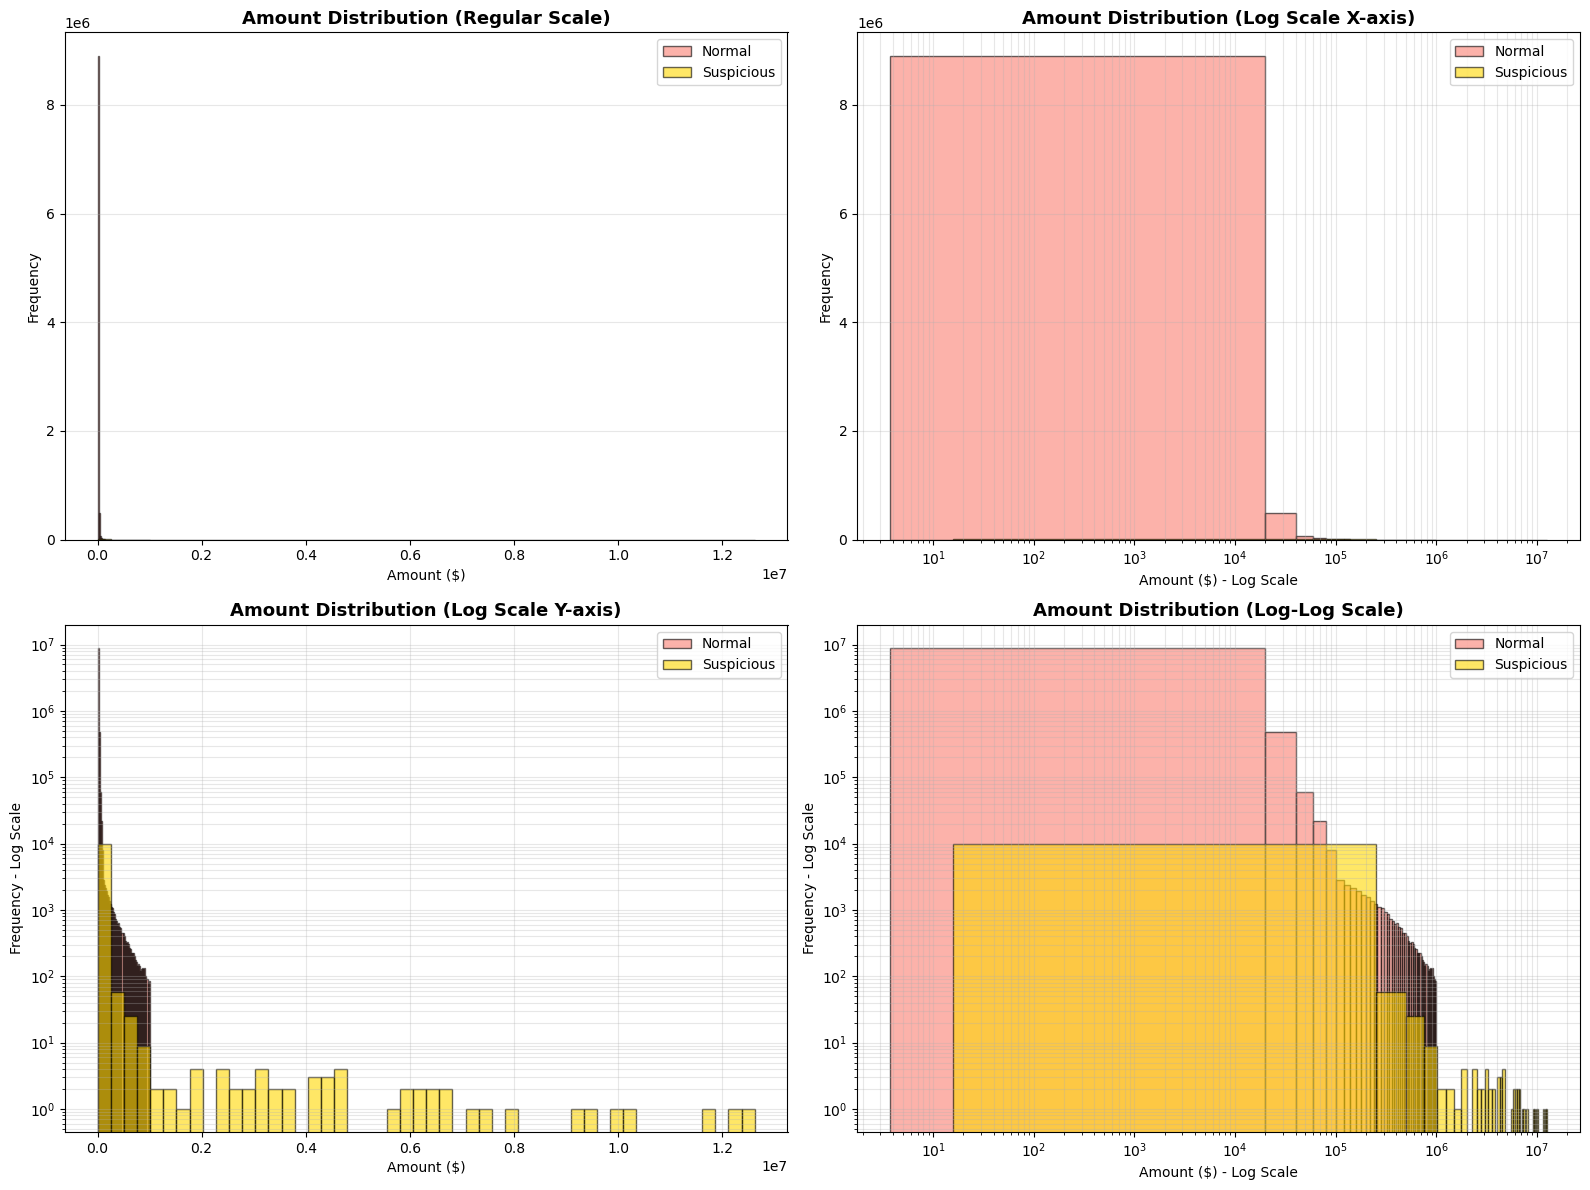

In [24]:
normal_amounts = df[df['Is_laundering'] == 0]['Amount']
suspicious_amounts = df[df['Is_laundering'] == 1]['Amount']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Regular Scale Histogram
axes[0, 0].hist(normal_amounts, bins=50, alpha=0.6, label='Normal', color='salmon', edgecolor='black')
axes[0, 0].hist(suspicious_amounts, bins=50, alpha=0.6, label='Suspicious', color='gold', edgecolor='black')
axes[0, 0].set_title('Amount Distribution (Regular Scale)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Log Scale on X-axis
axes[0, 1].hist(normal_amounts, bins=50, alpha=0.6, label='Normal', color='salmon', edgecolor='black')
axes[0, 1].hist(suspicious_amounts, bins=50, alpha=0.6, label='Suspicious', color='gold', edgecolor='black')
axes[0, 1].set_title('Amount Distribution (Log Scale X-axis)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Amount ($) - Log Scale')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xscale('log')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, which='both')

# 3. Log Scale on Y-axis
axes[1, 0].hist(normal_amounts, bins=50, alpha=0.6, label='Normal', color='salmon', edgecolor='black')
axes[1, 0].hist(suspicious_amounts, bins=50, alpha=0.6, label='Suspicious', color='gold', edgecolor='black')
axes[1, 0].set_title('Amount Distribution (Log Scale Y-axis)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Amount ($)')
axes[1, 0].set_ylabel('Frequency - Log Scale')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')

# 4. Log-Log Scale (both axes)
axes[1, 1].hist(normal_amounts, bins=50, alpha=0.6, label='Normal', color='salmon', edgecolor='black')
axes[1, 1].hist(suspicious_amounts, bins=50, alpha=0.6, label='Suspicious', color='gold', edgecolor='black')
axes[1, 1].set_title('Amount Distribution (Log-Log Scale)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Amount ($) - Log Scale')
axes[1, 1].set_ylabel('Frequency - Log Scale')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 7. Payment type analysis
**Tasks**
1. Frequency of each payment type
2. Suspicious rate by payment type
3. Identify the top 5 payment types by suspicious rate (min N transactions)


In [16]:
print("=" * 70)
print("PAYMENT TYPE FREQUENCY ANALYSIS")
print("=" * 70)

# Count frequency of each payment type
payment_freq = df['Payment_type'].value_counts()
print("\nPayment Type Counts:")
print(payment_freq)

# With percentages
payment_pct = df['Payment_type'].value_counts(normalize=True) * 100
print("\nPayment Type Percentages:")
print(payment_pct.round(2))

# Combined view
payment_summary = pd.DataFrame({
    'Count': payment_freq,
    'Percentage': payment_pct.round(2)
})
print("\nSummary Table:")
print(payment_summary)

PAYMENT TYPE FREQUENCY ANALYSIS

Payment Type Counts:
Payment_type
Credit card        2012909
Debit card         2012103
Cheque             2011419
ACH                2008807
Cross-border        933931
Cash Withdrawal     300477
Cash Deposit        225206
Name: count, dtype: int64

Payment Type Percentages:
Payment_type
Credit card        21.18
Debit card         21.17
Cheque             21.16
ACH                21.13
Cross-border        9.83
Cash Withdrawal     3.16
Cash Deposit        2.37
Name: proportion, dtype: float64

Summary Table:
                   Count  Percentage
Payment_type                        
Credit card      2012909       21.18
Debit card       2012103       21.17
Cheque           2011419       21.16
ACH              2008807       21.13
Cross-border      933931        9.83
Cash Withdrawal   300477        3.16
Cash Deposit      225206        2.37


In [25]:
print("=" * 70)
print("SUSPICIOUS RATE BY PAYMENT TYPE")
print("=" * 70)

# Calculate suspicious rate for each payment type
suspicious_rate = df.groupby('Payment_type')['Is_laundering'].agg(['sum', 'count', 'mean'])
suspicious_rate.columns = ['Laundering_Cases', 'Total_Transactions', 'Laundering_Rate']
suspicious_rate['Laundering_Rate'] = suspicious_rate['Laundering_Rate'] * 100  # Convert to percentage
suspicious_rate['Normal_Cases'] = suspicious_rate['Total_Transactions'] - suspicious_rate['Laundering_Cases']

# Sort by laundering rate
suspicious_rate_sorted = suspicious_rate.sort_values('Laundering_Rate', ascending=False)

print("\nSuspicious Rate by Payment Type:")
print(suspicious_rate_sorted)

# Overall baseline
overall_rate = df['Is_laundering'].mean() * 100
print(f"\n Overall Laundering Rate (Baseline): {overall_rate:.2f}%")

SUSPICIOUS RATE BY PAYMENT TYPE

Suspicious Rate by Payment Type:
                 Laundering_Cases  Total_Transactions  Laundering_Rate  \
Payment_type                                                             
Cash Deposit                 1405              225206         0.623873   
Cash Withdrawal              1334              300477         0.443961   
Cross-border                 2628              933931         0.281391   
ACH                          1159             2008807         0.057696   
Credit card                  1136             2012909         0.056436   
Debit card                   1124             2012103         0.055862   
Cheque                       1087             2011419         0.054041   

                 Normal_Cases  
Payment_type                   
Cash Deposit           223801  
Cash Withdrawal        299143  
Cross-border           931303  
ACH                   2007648  
Credit card           2011773  
Debit card            2010979  
Cheque     

## 8. Location analysis
**Tasks**
1. Frequency of sender and receiver locations
2. Suspicious rate by location
3. Compare “high-risk regions” (e.g., Mexico, Turkey, Morocco, UAE) vs others


In [18]:
print("=" * 70)
print("LOCATION FREQUENCY ANALYSIS")
print("=" * 70)

# Sender locations
print("\n" + "="*70)
print("SENDER BANK LOCATIONS")
print("="*70)
sender_freq = df['Sender_bank_location'].value_counts()
sender_pct = df['Sender_bank_location'].value_counts(normalize=True) * 100

sender_summary = pd.DataFrame({
    'Count': sender_freq,
    'Percentage': sender_pct.round(2)
})
print(sender_summary)

# Receiver locations
print("\n" + "="*70)
print("RECEIVER BANK LOCATIONS")
print("="*70)
receiver_freq = df['Receiver_bank_location'].value_counts()
receiver_pct = df['Receiver_bank_location'].value_counts(normalize=True) * 100

receiver_summary = pd.DataFrame({
    'Count': receiver_freq,
    'Percentage': receiver_pct.round(2)
})
print(receiver_summary)

# Summary statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Number of unique sender locations:   {df['Sender_bank_location'].nunique()}")
print(f"Number of unique receiver locations: {df['Receiver_bank_location'].nunique()}")
print(f"Most common sender location:   {sender_freq.idxmax()} ({sender_freq.max():,} transactions)")
print(f"Most common receiver location: {receiver_freq.idxmax()} ({receiver_freq.max():,} transactions)")

LOCATION FREQUENCY ANALYSIS

SENDER BANK LOCATIONS
                        Count  Percentage
Sender_bank_location                     
UK                    9183088       96.61
Turkey                  20902        0.22
Switzerland             20503        0.22
Pakistan                20346        0.21
UAE                     20081        0.21
Nigeria                 20027        0.21
Spain                   19391        0.20
Germany                 19259        0.20
USA                     19027        0.20
Italy                   18895        0.20
France                  18702        0.20
Japan                   18468        0.19
Morocco                 18437        0.19
Austria                 18050        0.19
Mexico                  17662        0.19
Albania                 17648        0.19
India                   17596        0.19
Netherlands             16770        0.18

RECEIVER BANK LOCATIONS
                          Count  Percentage
Receiver_bank_location                  

In [26]:
print("=" * 70)
print("SUSPICIOUS RATE BY LOCATION ANALYSIS")
print("=" * 70)

# Overall baseline
overall_rate = df['Is_laundering'].mean() * 100
print(f"\n Overall Laundering Rate (Baseline): {overall_rate:.2f}%")

# Sender location analysis
print("\n" + "=" * 70)
print("SUSPICIOUS RATE BY SENDER LOCATION")
print("=" * 70)

sender_analysis = df.groupby('Sender_bank_location')['Is_laundering'].agg(['sum', 'count', 'mean'])
sender_analysis.columns = ['Laundering_Cases', 'Total_Transactions', 'Laundering_Rate']
sender_analysis['Laundering_Rate'] = sender_analysis['Laundering_Rate'] * 100
sender_analysis['Normal_Cases'] = sender_analysis['Total_Transactions'] - sender_analysis['Laundering_Cases']
sender_analysis = sender_analysis.sort_values('Laundering_Rate', ascending=False)

print("\n", sender_analysis)

# Receiver location analysis
print("\n" + "=" * 70)
print("SUSPICIOUS RATE BY RECEIVER LOCATION")
print("=" * 70)

receiver_analysis = df.groupby('Receiver_bank_location')['Is_laundering'].agg(['sum', 'count', 'mean'])
receiver_analysis.columns = ['Laundering_Cases', 'Total_Transactions', 'Laundering_Rate']
receiver_analysis['Laundering_Rate'] = receiver_analysis['Laundering_Rate'] * 100
receiver_analysis['Normal_Cases'] = receiver_analysis['Total_Transactions'] - receiver_analysis['Laundering_Cases']
receiver_analysis = receiver_analysis.sort_values('Laundering_Rate', ascending=False)

print("\n", receiver_analysis)

SUSPICIOUS RATE BY LOCATION ANALYSIS

 Overall Laundering Rate (Baseline): 0.10%

SUSPICIOUS RATE BY SENDER LOCATION

                       Laundering_Cases  Total_Transactions  Laundering_Rate  \
Sender_bank_location                                                          
Morocco                             55               18437         0.298313   
Mexico                              44               17662         0.249122   
Netherlands                         41               16770         0.244484   
India                               42               17596         0.238691   
Italy                               45               18895         0.238158   
Germany                             43               19259         0.223272   
Austria                             38               18050         0.210526   
Japan                               38               18468         0.205761   
Switzerland                         41               20503         0.199971   
USA         

In [20]:
print("=" * 70)
print("HIGH-RISK REGIONS ANALYSIS")
print("=" * 70)

# Define high-risk regions (based on common money laundering concerns)
high_risk_regions = ['Mexico', 'Turkey', 'Morocco', 'UAE', 'United Arab Emirates']

# Note: Adjust these based on what's actually in your data
print("\nDefined high-risk regions:", high_risk_regions)
print("\nActual locations in dataset:")
print("Sender locations:", df['Sender_bank_location'].unique())
print("Receiver locations:", df['Receiver_bank_location'].unique())

# Create risk flags for sender
df['Sender_is_high_risk'] = df['Sender_bank_location'].isin(high_risk_regions).astype(int)

# Create risk flags for receiver
df['Receiver_is_high_risk'] = df['Receiver_bank_location'].isin(high_risk_regions).astype(int)

# Combined risk flag (either sender OR receiver is high-risk)
df['Any_high_risk'] = ((df['Sender_is_high_risk'] == 1) | (df['Receiver_is_high_risk'] == 1)).astype(int)

# Both high-risk
df['Both_high_risk'] = ((df['Sender_is_high_risk'] == 1) & (df['Receiver_is_high_risk'] == 1)).astype(int)

print(f"\n✓ Created risk flags")

HIGH-RISK REGIONS ANALYSIS

Defined high-risk regions: ['Mexico', 'Turkey', 'Morocco', 'UAE', 'United Arab Emirates']

Actual locations in dataset:
Sender locations: ['UK' 'Albania' 'Nigeria' 'Japan' 'Spain' 'Switzerland' 'UAE' 'Italy'
 'France' 'Pakistan' 'Mexico' 'Austria' 'Germany' 'Turkey' 'India'
 'Morocco' 'USA' 'Netherlands']
Receiver locations: ['UK' 'UAE' 'Spain' 'France' 'USA' 'Mexico' 'Albania' 'Turkey' 'Nigeria'
 'Switzerland' 'Italy' 'Germany' 'Austria' 'Netherlands' 'India'
 'Pakistan' 'Morocco' 'Japan']

✓ Created risk flags
